In [ ]:
#install dependecies in enviroment
!pip install fastapi uvicorn python-multipart  rembg numpy opencv-contrib-python "rembg[cpu]" 

In [ ]:
import cv2
import numpy as np
import os
import sys
import time
from PIL import Image
# maybe ill do the bonus part but for now ill import it anyways
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
from rembg import remove
from PIL import Image

In [50]:
def findBESTCardContour(imagname, filePath):
    # background removal
    # i noticed that it works better on an id with no background
    inputImage = Image.open(filePath)
    noBG = remove(inputImage)
    noBG = np.array(noBG) 
    show_img("no background", noBG)

   # alpha to mask foreground
    alpha = noBG[:,:,3]
    _, fgmask = cv2.threshold(alpha, 0, 255, cv2.THRESH_BINARY)
    show_img("Foreground Mask", fgmask)

    # clean up 
    kerfg = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_CLOSE, kerfg, iterations=2)
    fgmask = cv2.dilate(fgmask, kerfg, iterations=2)

    fgcontours, _ = cv2.findContours(fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not fgcontours:
        return None

    largestfg = max(fgcontours, key=cv2.contourArea)
    hull = cv2.convexHull(largestfg)
    filledmask = np.zeros_like(fgmask)
    cv2.drawContours(filledmask, [hull], -1, 255, -1)
    show_img("Filled Foreground Mask", filledmask)

# crop to box of foreground region 
# threshold/contour cascade below has less background
    x, y, w, h = cv2.boundingRect(hull)
    pad_x = int(w * 0.15)
    pad_y = int(h * 0.15)
    x0, y0 = max(0, x - pad_x), max(0, y - pad_y)
    x1, y1 = min(imagname.shape[1], x + w + pad_x), min(imagname.shape[0], y + h + pad_y)
    cropped = imagname[y0:y1, x0:x1]
    show_img("Cropped Region", cropped)
    image = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(cropped, cv2.COLOR_BGR2HSV)
    sat = hsv[:,:,2]
    img_area = cropped.shape[0] * cropped.shape[1]
    ker = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    fgcrop = filledmask[y0:y1, x0:x1]
    candidates = [fgcrop]
    
# Otsu 
    _, Maskotso = cv2.threshold(sat,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    candidates.append(Maskotso)
#Otsu inverted 
    _, Maskotsoinv = cv2.threshold(sat,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    candidates.append(Maskotsoinv)
# adaptive threshold
    blr = cv2.GaussianBlur(image, (5,5), 0)
    adptiveGauss = cv2.adaptiveThreshold(blr,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,21,5)
    candidates.append(adptiveGauss)
# Canny
    can = cv2.Canny(blr,50,150,apertureSize=3)
    canny = cv2.morphologyEx(can,cv2.MORPH_CLOSE,ker,iterations=2)
    candidates.append(canny)
    quads = []
    for mask in candidates:
        m = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, ker, iterations=2)
        contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            area = cv2.contourArea(c)
            if area < 0.05 * img_area or area > 0.98 * img_area:
                continue
            for eps_factor in [0.02, 0.03, 0.04, 0.05, 0.07, 0.1]:
                epsilon = eps_factor * cv2.arcLength(c, True)
                approx = cv2.approxPolyDP(c, epsilon, True)
                if len(approx) == 4:
                    x_b, y_b, w_b, h_b = cv2.boundingRect(approx)
                    aspect = max(w_b, h_b) / min(w_b, h_b)
                    quads.append((approx, area, aspect))
                    break
    if not quads:
        return None
# cascade of filters to find best Candidate
# strict to loose
    filters = [
        lambda a, ar:
        0.3 * img_area < a < 0.9 * img_area and 1.45 < ar < 1.7,
        lambda a, ar: 
        0.2 * img_area < a < 0.95 * img_area and 1.3 < ar < 1.9,
        lambda a, ar: 
        0.1 * img_area < a < 0.98 * img_area and 1.1 < ar < 2.2,
        lambda a, ar: True,
    ]
    best = None
    for f in filters:
        matches = [(approx, area) for approx, area, aspect in quads if f(area, aspect)]
        if matches:
            matches.sort(key=lambda x: abs(x[1] - 0.5 * img_area))
            best = matches[0][0]
            break
    if best is None:
        return None
# shift back to original image 
    best = best.copy()
    best[:,0,0] += x0
    best[:,0,1] += y0
    return best

In [51]:
def PerspectiveTransform(imagname,filePath):
    cv2.imshow("Original Image", imagname)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    apprx = findBESTCardContour(imagname,filePath)
    if apprx is not None and len(apprx) >= 4:
        #get points of corners 
        points = np.array([point[0] for point in apprx], dtype = "float32")
        center = np.mean(points, axis=0)
        angles = np.arctan2(points[:,1] - center[1], points[:,0] - center[0])
        sortedInDx = np.argsort(angles)
        points = points[sortedInDx]
        #Get SUM and difference
        sum = points.sum(axis=1)
        diff = np.diff(points, axis=1)
        point=np.roll(points, -np.argmin(sum), axis=0)
        #topleft,bottomright ,topriht ,bottomleft
        topL = points[np.argmin(sum)]
        bottomR = points[np.argmax(sum)]
        topR = points[np.argmin(diff)]
        bottomL = points[np.argmax(diff)]
        #arrange in order
        orderP = np.array([topL, topR, bottomR, bottomL], dtype = "float32")
        #FOR TESTING : draw the contour on prev IMAGE
        cv2.drawContours(imagname, [apprx], -1, (0, 255, 0), 2)
        cv2.imshow("Contour", imagname)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
       
        windthMBE = np.linalg.norm(bottomR - bottomL)
        windthMTE = np.linalg.norm(topR - topL)
        maxWidth = max(int(windthMBE), int(windthMTE))
        # get max height
        heightMRE = np.linalg.norm(topR - bottomR)
        heightMLE = np.linalg.norm(topL - bottomL)
        maxHeight = max(int(heightMRE), int(heightMLE))
        # destination ppoints so that its a top-down, flat view
        destination = np.array([
        [0,0],
        [maxWidth - 1,0],
        [maxWidth - 1,maxHeight - 1],
        [0,maxHeight - 1]
        ],dtype="float32")
        debug_img = imagname.copy()
        labels = ["TL", "TR", "BR", "BL"]
        for i, p in enumerate(orderP):
            pt = tuple(p.astype(int))
            cv2.circle(debug_img, pt, 8, (0, 0, 255), -1)
            cv2.putText(debug_img, labels[i], pt, cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
        show_img("Corner Order", debug_img)
        Hmatrix = cv2.findHomography(orderP,destination)
        NewIMG = cv2.warpPerspective(imagname, Hmatrix[0], (maxWidth, maxHeight))
        cv2.imshow("Warped Image", NewIMG)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        return NewIMG
    else:
        print("NOT ENOUGH EDGES")
        return None

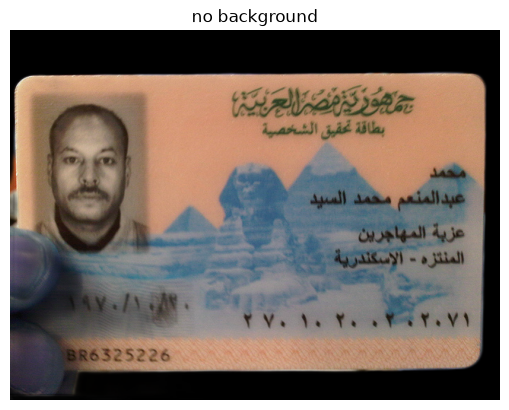

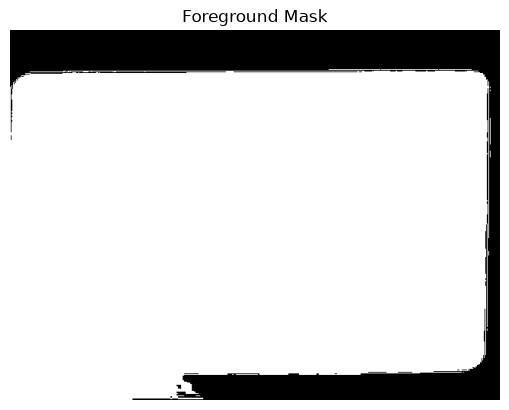

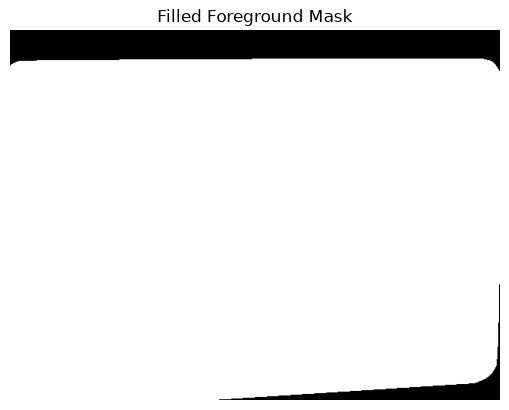

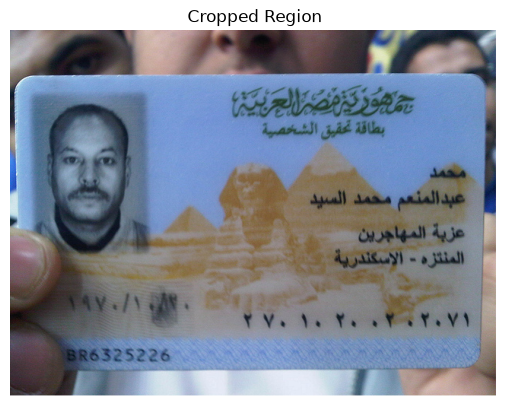

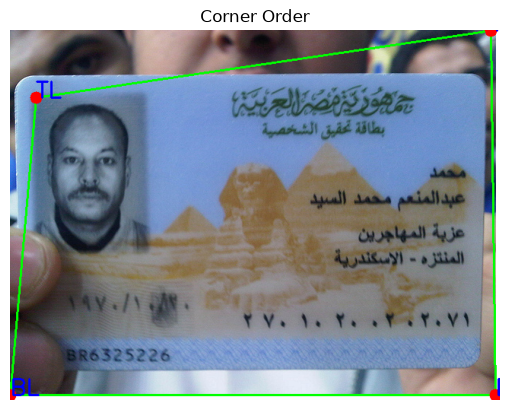

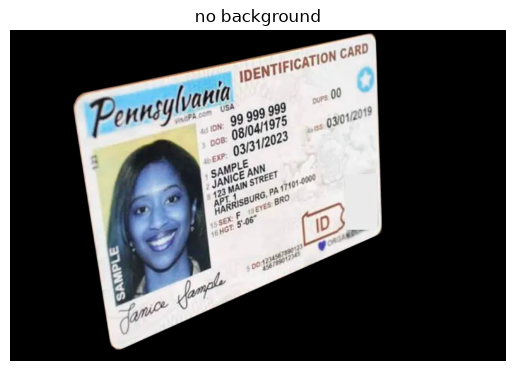

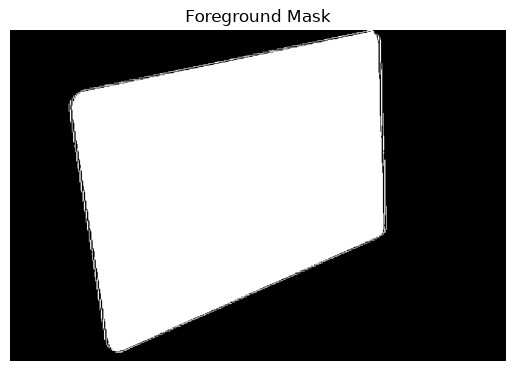

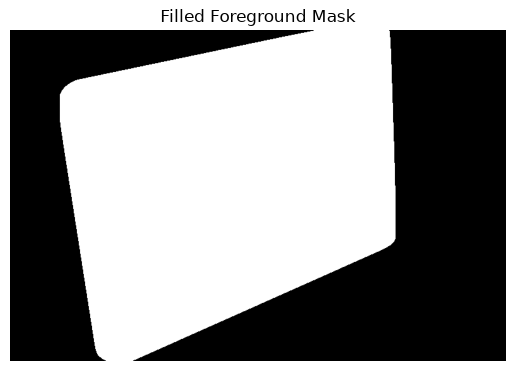

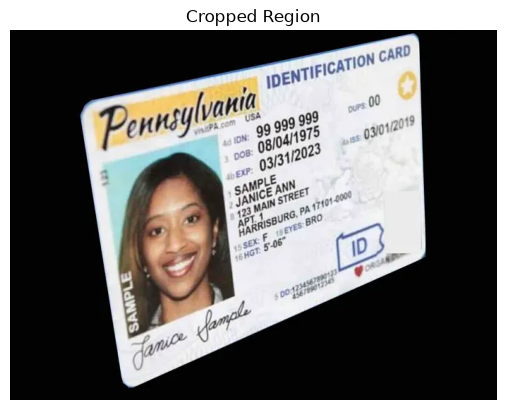

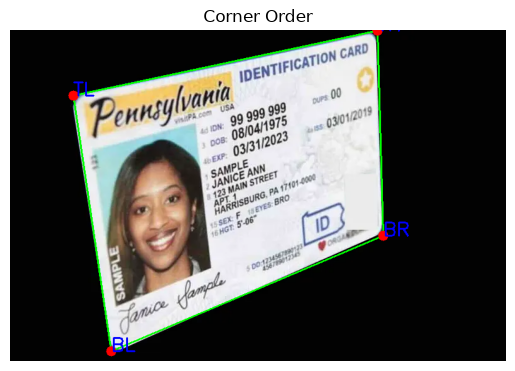

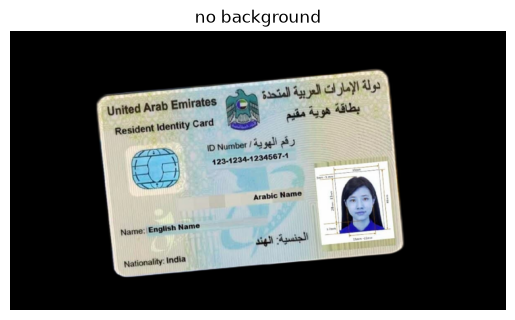

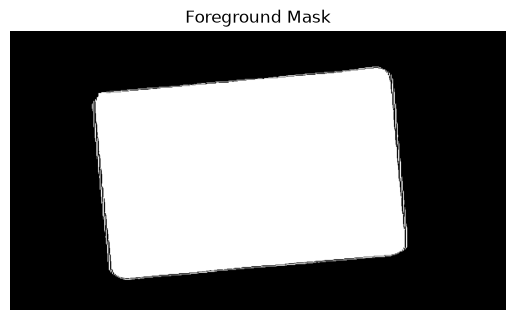

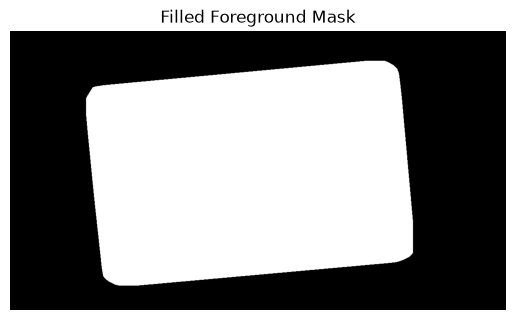

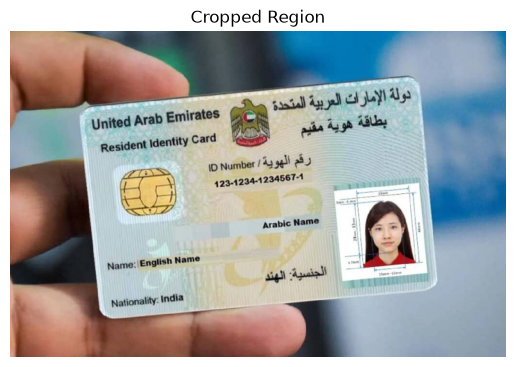

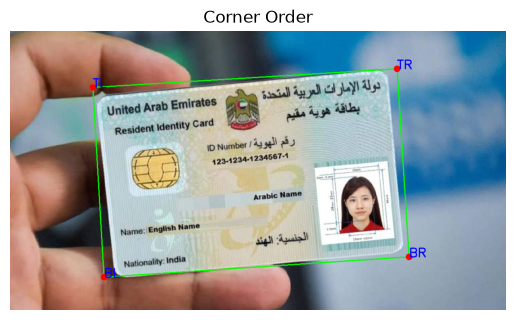

array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [ 23, 246,  18],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  7, 235,  16],
        [ 52, 104, 121],
        ...,
        [168, 188, 132],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[  0, 255,   0],
        [  0, 255,   0],
        [ 58,  94, 117],
        ...,
        [172, 186, 139],
        [ 23, 246,  19],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  8, 234,  16],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]]

In [52]:
PerspectiveTransform(cv2.imread("imagesToTest/testEgID.png"),"imagesToTest/testEgID.png")
PerspectiveTransform(cv2.imread("imagesToTest/test3.jpg"),"imagesToTest/test3.jpg")
PerspectiveTransform(cv2.imread("imagesToTest/test.jpg"),"imagesToTest/test.jpg")

In [ ]:
import matplotlib.pyplot as plt
#function to visualize in notebook 
def show_img(title, img):
    plt.figure()
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()